# Klasifikasi Prediksi Hujan - Rain in Australia

**Mata Kuliah:** Machine Learning  
**Dataset:** Rain in Australia (weatherAUS_sample.csv)  
**Sumber:** Kaggle - https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package  

**Tujuan:** Memprediksi apakah besok akan hujan (`RainTomorrow`) berdasarkan kondisi cuaca hari ini, menggunakan dan membandingkan tiga algoritma:
1. Logistic Regression
2. Decision Tree
3. Random Forest


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
sns.set_palette('Set2')

print("Library berhasil di-import!")
print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")


Library berhasil di-import!
Pandas  : 2.3.3
NumPy   : 2.4.0


## 2. Load & Eksplorasi Awal Dataset

In [2]:
import os

print("Current working directory:", os.getcwd())
print("\nIsi folder saat ini:")
for file in os.listdir('.'):
    print(f"  - {file}")

Current working directory: C:\Users\ASUS\Downloads\files (1)

Isi folder saat ini:
  - .ipynb_checkpoints
  - Rain_Prediction_Classification.ipynb
  - README.md
  - requirements.txt
  - weatherAUS.csv
  - weatherAUS_sample.csv


In [5]:
df = pd.read_csv('weatherAUS.csv')

print(f"Jumlah baris : {df.shape[0]}")
print(f"Jumlah kolom : {df.shape[1]}")
print(f"\nKolom: {list(df.columns)}")


Jumlah baris : 145460
Jumlah kolom : 23

Kolom: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']


In [6]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [8]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


## 3. Exploratory Data Analysis (EDA)

In [10]:
#Buat Folder images di Lokasi yang Benar
import os

# Buat folder images di direktori yang sama dengan notebook
os.makedirs('images', exist_ok=True)
print("Folder 'images' berhasil dibuat!")

Folder 'images' berhasil dibuat!


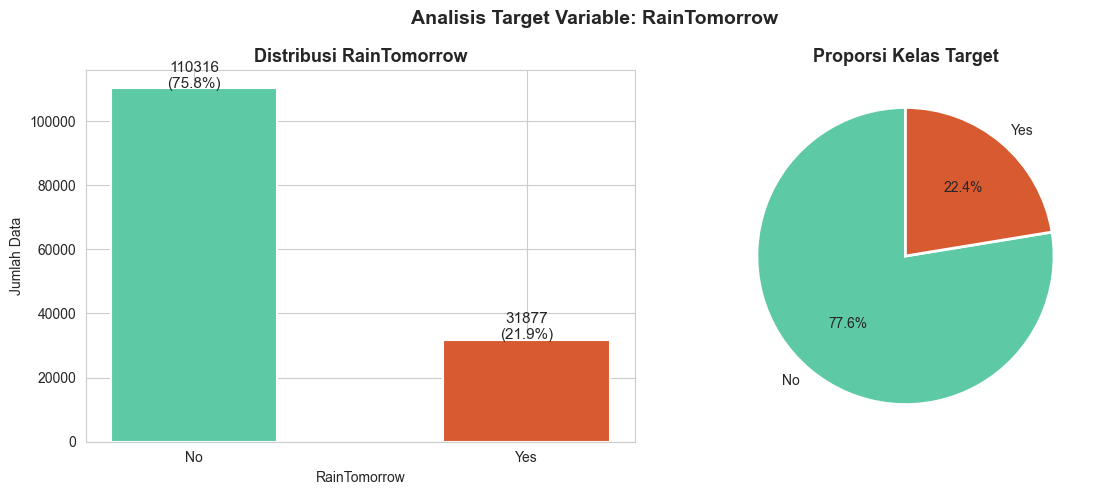

Distribusi kelas:
RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64


In [12]:
# 3.1 Distribusi Target Variable
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df['RainTomorrow'].value_counts()
colors = ['#5DCAA5', '#D85A30']

axes[0].bar(counts.index, counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi RainTomorrow', fontweight='bold', fontsize=13)
axes[0].set_xlabel('RainTomorrow')
axes[0].set_ylabel('Jumlah Data')
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 5, f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporsi Kelas Target', fontweight='bold', fontsize=13)

plt.suptitle('Analisis Target Variable: RainTomorrow', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Distribusi kelas:\n{counts}")


Missing Values per Kolom:
               Jumlah Missing  Persentase (%)
Sunshine                69835           48.01
Evaporation             62790           43.17
Cloud3pm                59358           40.81
Cloud9am                55888           38.42
Pressure9am             15065           10.36
Pressure3pm             15028           10.33
WindDir9am              10566            7.26
WindGustDir             10326            7.10
WindGustSpeed           10263            7.06
Humidity3pm              4507            3.10
WindDir3pm               4228            2.91
Temp3pm                  3609            2.48
RainTomorrow             3267            2.25
Rainfall                 3261            2.24
RainToday                3261            2.24
WindSpeed3pm             3062            2.11
Humidity9am              2654            1.82
WindSpeed9am             1767            1.21
Temp9am                  1767            1.21
MinTemp                  1485            1.02
MaxTemp 

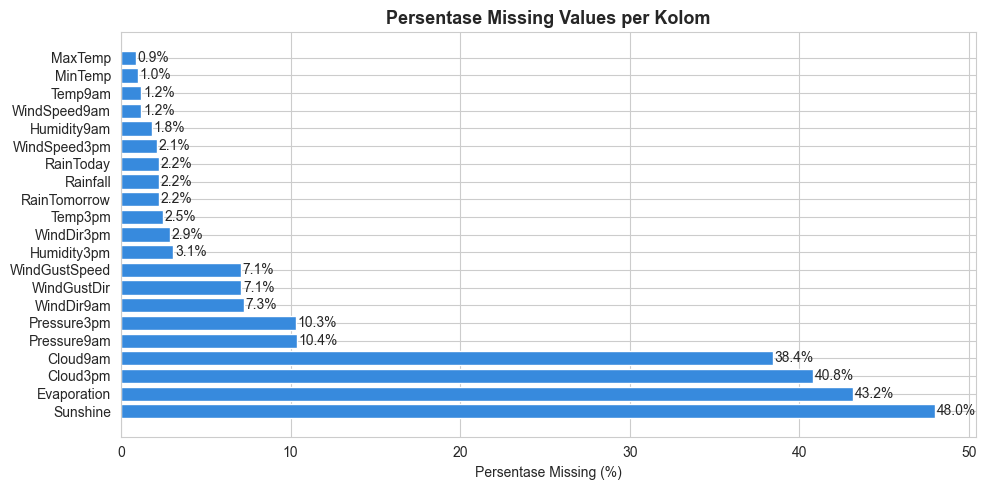

In [14]:
# 3.2 Analisis Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Persentase (%)', ascending=False)

print("Missing Values per Kolom:")
print(missing_df)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index, missing_df['Persentase (%)'], color='#378ADD', edgecolor='white')
ax.set_xlabel('Persentase Missing (%)')
ax.set_title('Persentase Missing Values per Kolom', fontweight='bold', fontsize=13)
for bar, val in zip(bars, missing_df['Persentase (%)']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('images/02_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()


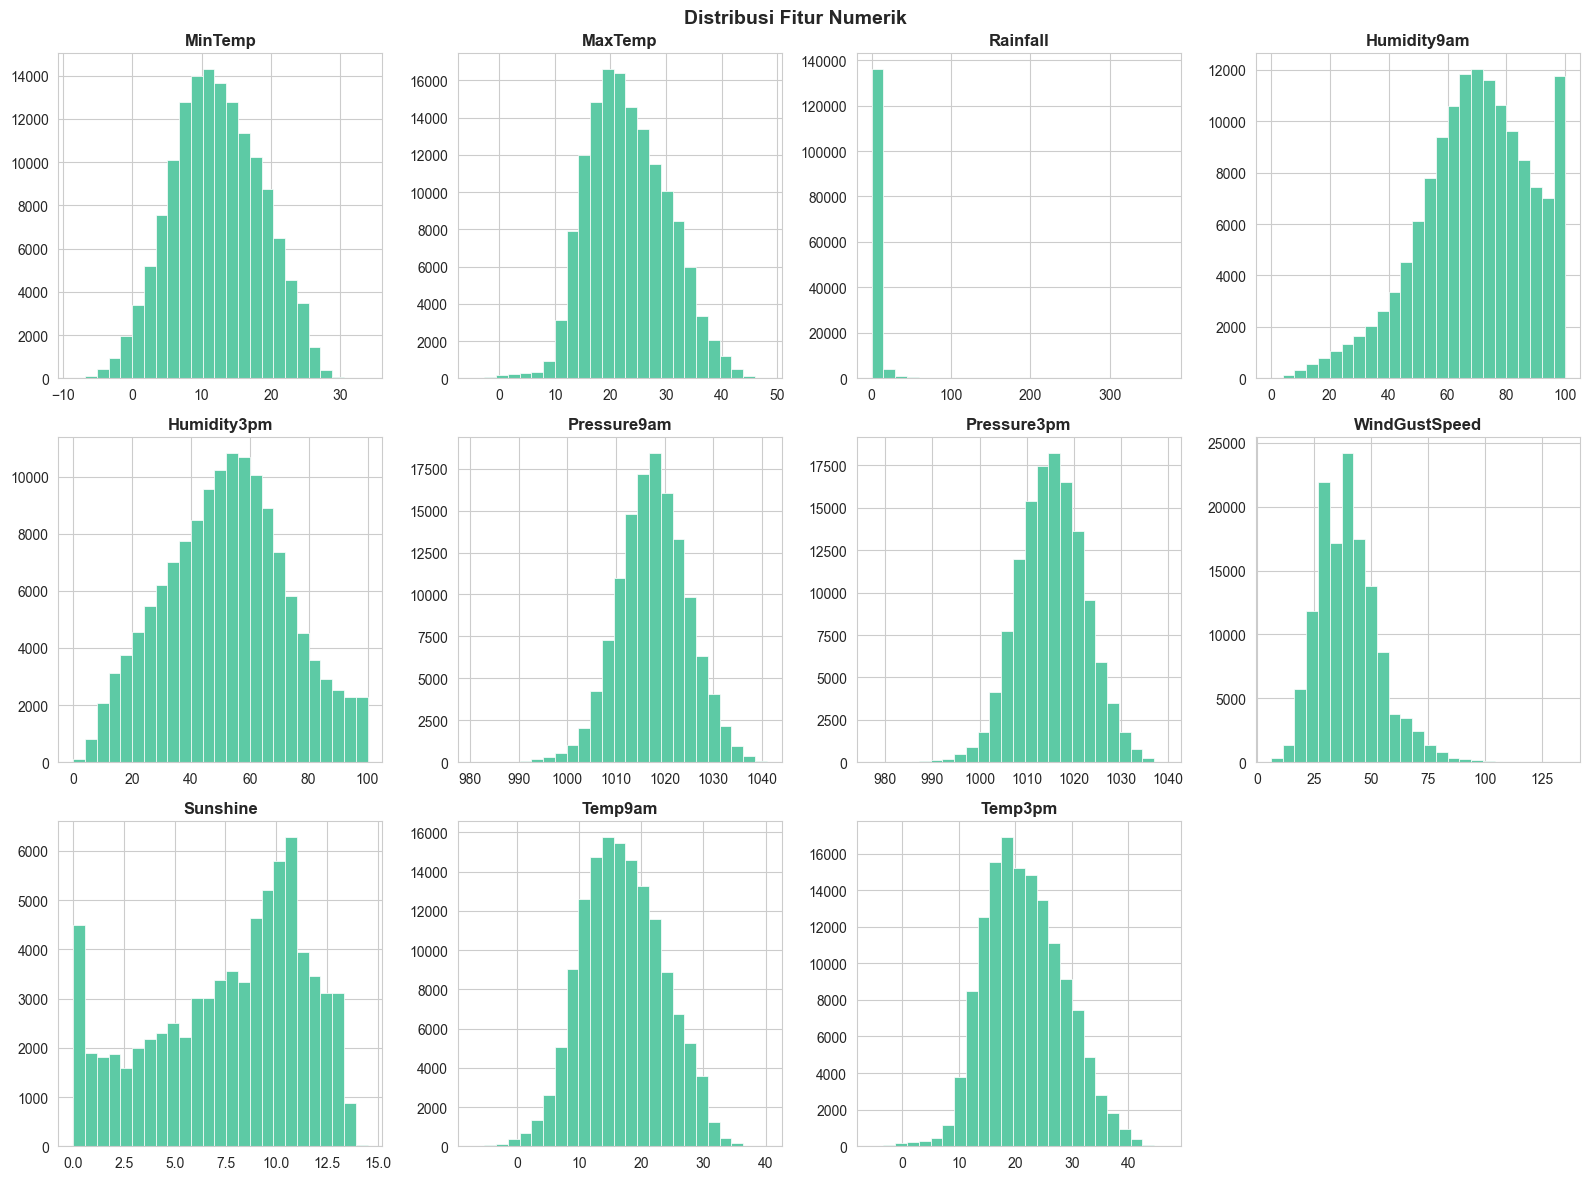

In [16]:
# 3.3 Distribusi Fitur Numerik
numeric_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am',
                'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                'WindGustSpeed', 'Sunshine', 'Temp9am', 'Temp3pm']

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    df[col].dropna().hist(ax=axes[i], bins=25, color='#5DCAA5', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontweight='bold')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/03_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


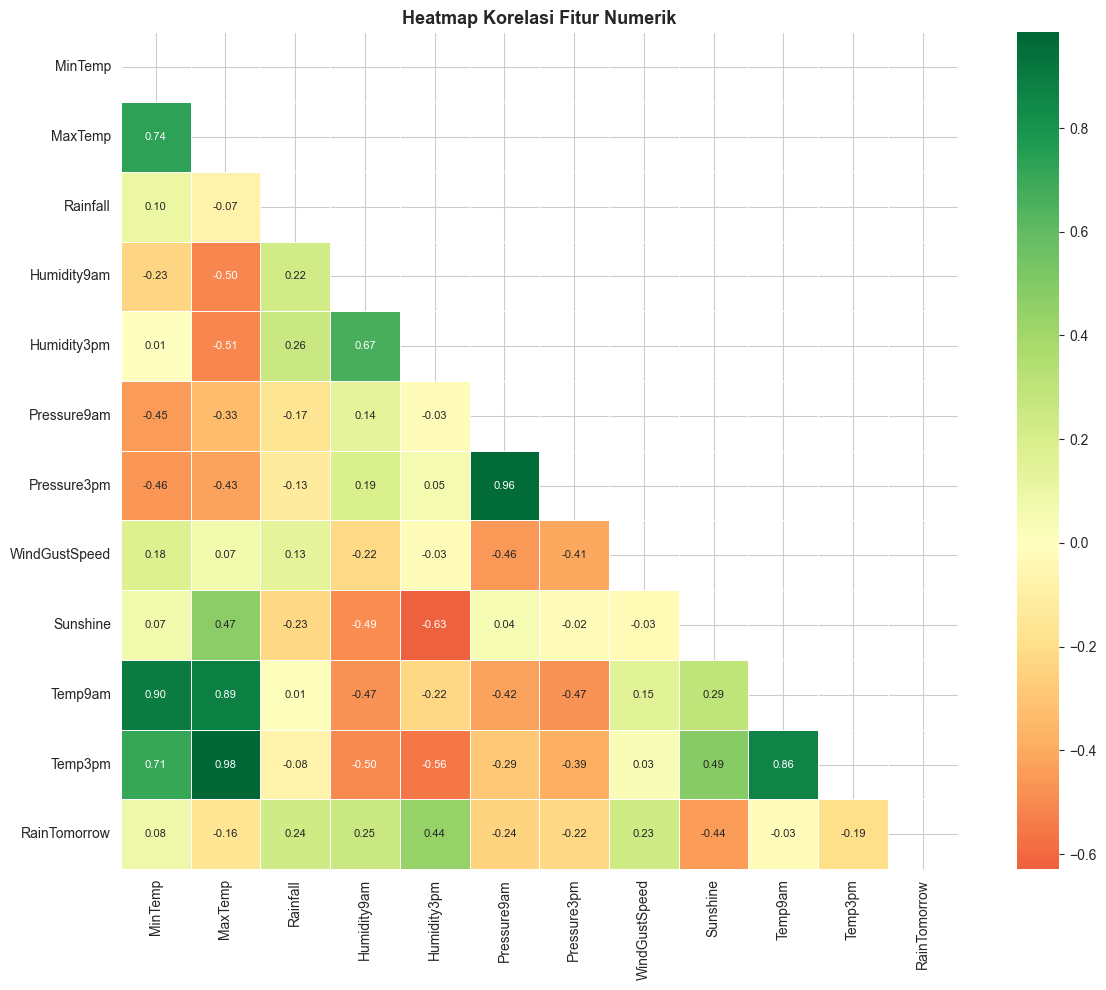

Korelasi dengan RainTomorrow (absolut):
Sunshine         0.443561
Humidity3pm      0.439929
Humidity9am      0.253657
Pressure9am      0.243348
Rainfall         0.236461
WindGustSpeed    0.229195
Pressure3pm      0.223351
Temp3pm          0.190073
MaxTemp          0.157141
MinTemp          0.082455
Temp9am          0.025685
Name: RainTomorrow, dtype: float64


In [18]:
# 3.4 Heatmap Korelasi
numeric_df = df[numeric_cols].copy()
numeric_df['RainTomorrow'] = (df['RainTomorrow'] == 'Yes').astype(int)
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Heatmap Korelasi Fitur Numerik', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('images/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

corr_target = corr_matrix['RainTomorrow'].drop('RainTomorrow').abs().sort_values(ascending=False)
print("Korelasi dengan RainTomorrow (absolut):")
print(corr_target)


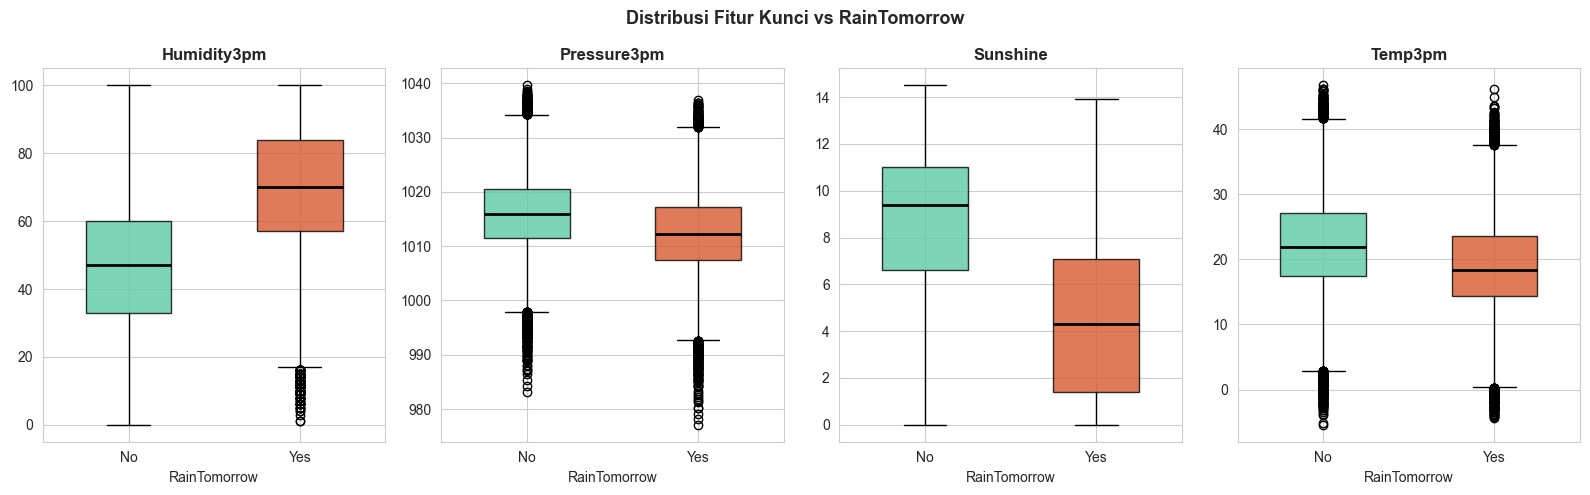

In [20]:
# 3.5 Boxplot Fitur Kunci vs Target
key_features = ['Humidity3pm', 'Pressure3pm', 'Sunshine', 'Temp3pm']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, feat in enumerate(key_features):
    temp_df = df[[feat, 'RainTomorrow']].dropna()
    groups = [temp_df[temp_df['RainTomorrow'] == cat][feat].values for cat in ['No', 'Yes']]
    bp = axes[i].boxplot(groups, patch_artist=True, labels=['No', 'Yes'],
                          widths=0.5, medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#5DCAA5', '#D85A30']):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('RainTomorrow')

plt.suptitle('Distribusi Fitur Kunci vs RainTomorrow', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/05_boxplot_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Preprocessing Data

In [21]:
df_clean = df.copy()
print(f"Shape awal: {df_clean.shape}")
print(f"Missing values total: {df_clean.isnull().sum().sum()}")


Shape awal: (145460, 23)
Missing values total: 343248


In [22]:
# Imputasi: numerik -> median, kategorik -> modus
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f"Missing values setelah imputasi: {df_clean.isnull().sum().sum()}")
print(f"Shape: {df_clean.shape}")


Missing values setelah imputasi: 0
Shape: (145460, 23)


In [23]:
# Label Encoding variabel kategorik
le = LabelEncoder()
cat_encode_cols = [c for c in cat_cols if c != 'RainTomorrow']
for col in cat_encode_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# Encode target
df_clean['RainTomorrow'] = (df_clean['RainTomorrow'] == 'Yes').astype(int)
print("Encoding selesai.")
print(f"Distribusi target: {df_clean['RainTomorrow'].value_counts().to_dict()}")


Encoding selesai.
Distribusi target: {0: 113583, 1: 31877}


In [24]:
# Split fitur dan target
X = df_clean.drop('RainTomorrow', axis=1)
y = df_clean['RainTomorrow']

# Train-test split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data training : {X_train.shape[0]} sampel")
print(f"Data testing  : {X_test.shape[0]} sampel")

# Standarisasi (untuk Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Standarisasi selesai.")


Data training : 116368 sampel
Data testing  : 29092 sampel
Standarisasi selesai.


## 5. Pengembangan Model Machine Learning

In [25]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)

print("MODEL 1: LOGISTIC REGRESSION")
print(f"Accuracy  : {acc_lr*100:.2f}%")
print(f"Precision : {prec_lr:.4f}")
print(f"Recall    : {rec_lr:.4f}")
print(f"F1-Score  : {f1_lr:.4f}")
print(f"AUC-ROC   : {auc_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Rain', 'Rain']))


MODEL 1: LOGISTIC REGRESSION
Accuracy  : 84.70%
Precision : 0.7239
Recall    : 0.4878
F1-Score  : 0.5829
AUC-ROC   : 0.8621

              precision    recall  f1-score   support

     No Rain       0.87      0.95      0.91     22717
        Rain       0.72      0.49      0.58      6375

    accuracy                           0.85     29092
   macro avg       0.80      0.72      0.74     29092
weighted avg       0.84      0.85      0.84     29092



In [26]:
# Model 2: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=8,
                                   min_samples_split=10, min_samples_leaf=5)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt  = recall_score(y_test, y_pred_dt)
f1_dt   = f1_score(y_test, y_pred_dt)
auc_dt  = roc_auc_score(y_test, y_prob_dt)

print("MODEL 2: DECISION TREE")
print(f"Accuracy  : {acc_dt*100:.2f}%")
print(f"Precision : {prec_dt:.4f}")
print(f"Recall    : {rec_dt:.4f}")
print(f"F1-Score  : {f1_dt:.4f}")
print(f"AUC-ROC   : {auc_dt:.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=['No Rain', 'Rain']))


MODEL 2: DECISION TREE
Accuracy  : 84.38%
Precision : 0.7200
Recall    : 0.4698
F1-Score  : 0.5686
AUC-ROC   : 0.8496

              precision    recall  f1-score   support

     No Rain       0.86      0.95      0.90     22717
        Rain       0.72      0.47      0.57      6375

    accuracy                           0.84     29092
   macro avg       0.79      0.71      0.74     29092
weighted avg       0.83      0.84      0.83     29092



In [27]:
# Model 3: Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100,
                                   max_depth=10, min_samples_split=10,
                                   min_samples_leaf=5, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_prob_rf)

print("MODEL 3: RANDOM FOREST")
print(f"Accuracy  : {acc_rf*100:.2f}%")
print(f"Precision : {prec_rf:.4f}")
print(f"Recall    : {rec_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")
print(f"AUC-ROC   : {auc_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['No Rain', 'Rain']))


MODEL 3: RANDOM FOREST
Accuracy  : 85.17%
Precision : 0.7758
Recall    : 0.4549
F1-Score  : 0.5735
AUC-ROC   : 0.8714

              precision    recall  f1-score   support

     No Rain       0.86      0.96      0.91     22717
        Rain       0.78      0.45      0.57      6375

    accuracy                           0.85     29092
   macro avg       0.82      0.71      0.74     29092
weighted avg       0.84      0.85      0.84     29092



## 6. Evaluasi & Perbandingan Model

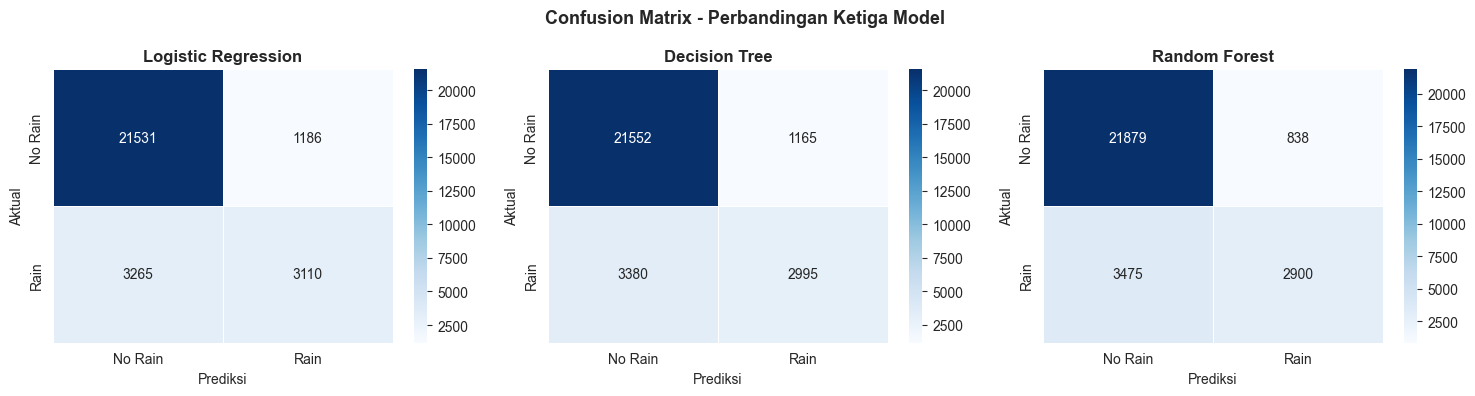

In [29]:
# Confusion Matrix ketiga model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_info = [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree',       y_pred_dt),
    ('Random Forest',       y_pred_rf),
]
for ax, (name, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['No Rain', 'Rain'],
                yticklabels=['No Rain', 'Rain'], linewidths=0.5)
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_ylabel('Aktual')
    ax.set_xlabel('Prediksi')
plt.suptitle('Confusion Matrix - Perbandingan Ketiga Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/06_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


In [30]:
# Tabel perbandingan metrik
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [acc_lr, acc_dt, acc_rf],
    'Precision': [prec_lr, prec_dt, prec_rf],
    'Recall': [rec_lr, rec_dt, rec_rf],
    'F1-Score': [f1_lr, f1_dt, f1_rf],
    'AUC-ROC': [auc_lr, auc_dt, auc_rf],
}
results_df = pd.DataFrame(results)
display_df = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']:
    display_df[col] = display_df[col].apply(lambda x: f'{x*100:.2f}%')

print(display_df.to_string(index=False))
best_idx = results_df['F1-Score'].idxmax()
print(f"\nModel terbaik berdasarkan F1-Score: {results_df.iloc[best_idx]['Model']}")


              Model Accuracy Precision Recall F1-Score AUC-ROC
Logistic Regression   84.70%    72.39% 48.78%   58.29%  86.21%
      Decision Tree   84.38%    72.00% 46.98%   56.86%  84.96%
      Random Forest   85.17%    77.58% 45.49%   57.35%  87.14%

Model terbaik berdasarkan F1-Score: Logistic Regression


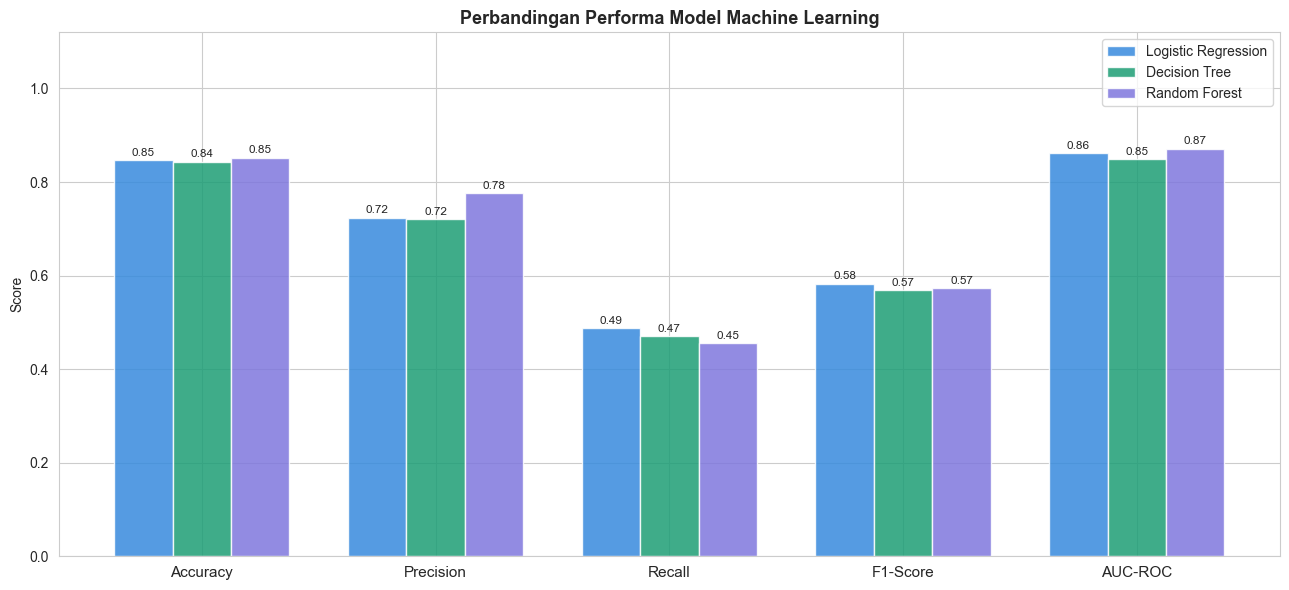

In [32]:
# Bar chart perbandingan metrik
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#378ADD', '#1D9E75', '#7F77DD']
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
values_list = [
    [acc_lr, prec_lr, rec_lr, f1_lr, auc_lr],
    [acc_dt, prec_dt, rec_dt, f1_dt, auc_dt],
    [acc_rf, prec_rf, rec_rf, f1_rf, auc_rf],
]
for i, (name, vals, color) in enumerate(zip(model_names, values_list, colors)):
    bars = ax.bar(x + i*width, vals, width, label=name, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.set_title('Perbandingan Performa Model Machine Learning', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('images/07_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


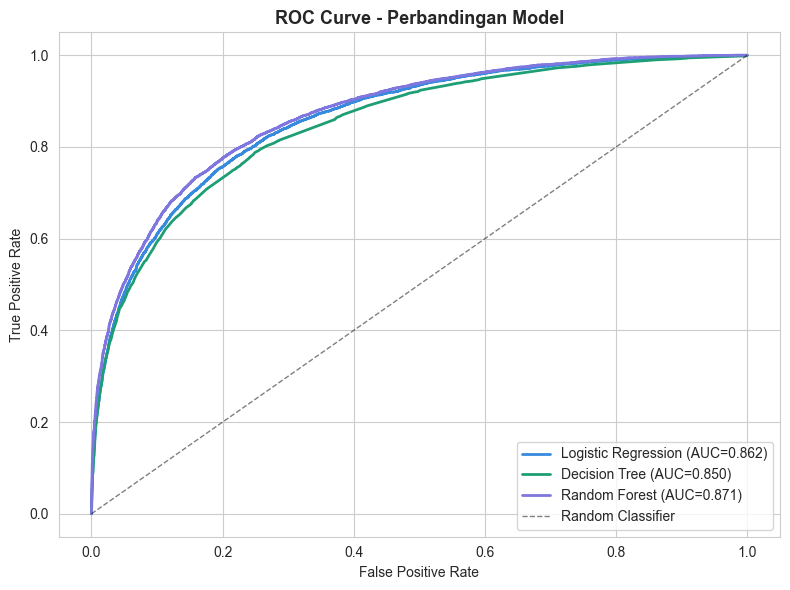

In [34]:
# ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr, '#378ADD'),
    ('Decision Tree',       y_prob_dt, '#1D9E75'),
    ('Random Forest',       y_prob_rf, '#7F77DD'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Perbandingan Model', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('images/08_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


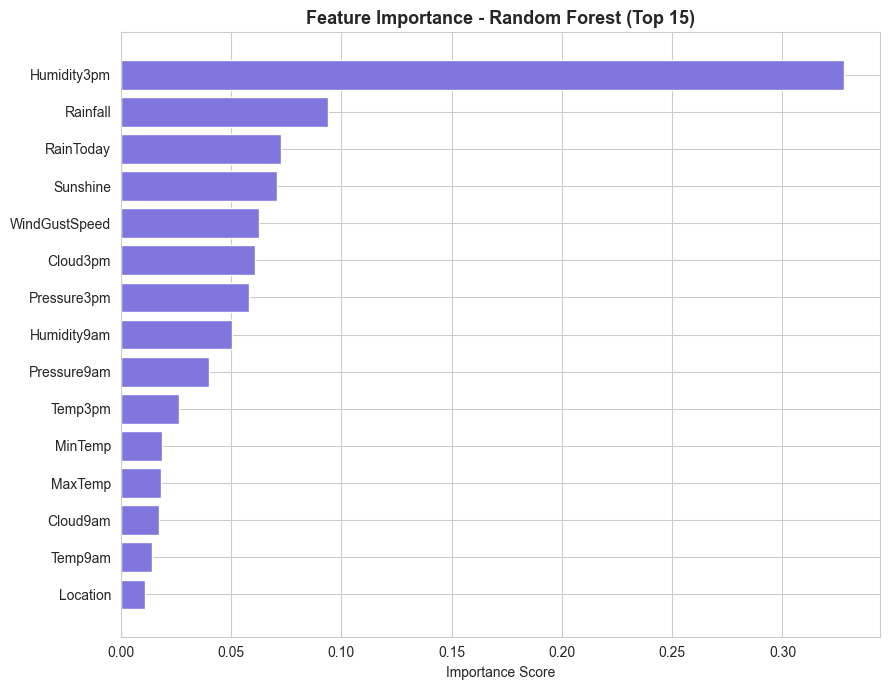

Top 5 Fitur Terpenting:
  Humidity3pm              : 0.3278
  Rainfall                 : 0.0941
  RainToday                : 0.0724
  Sunshine                 : 0.0709
  WindGustSpeed            : 0.0626


In [36]:
# Feature Importance (Random Forest)
feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(feat_importance.index, feat_importance.values, color='#7F77DD', edgecolor='white')
ax.set_title('Feature Importance - Random Forest (Top 15)', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('images/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 Fitur Terpenting:")
for feat, val in feat_importance.sort_values(ascending=False).head(5).items():
    print(f"  {feat:25s}: {val:.4f}")


In [37]:
# Cross Validation
print("Cross Validation (5-fold) - F1-Score:")
for name, model, X_data in [
    ('Logistic Regression', lr_model, X_train_scaled),
    ('Decision Tree',       dt_model, X_train),
    ('Random Forest',       rf_model, X_train),
]:
    cv_scores = cross_val_score(model, X_data, y_train, cv=5, scoring='f1')
    print(f"  {name:22s}: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")


Cross Validation (5-fold) - F1-Score:
  Logistic Regression   : 0.5686 +/- 0.0018
  Decision Tree         : 0.5581 +/- 0.0106
  Random Forest         : 0.5605 +/- 0.0031


## 7. Kesimpulan

In [38]:
print("RINGKASAN HASIL EVALUASI MODEL")
print("-" * 65)
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-" * 65)
for name, acc, prec, rec, f1, auc in [
    ('Logistic Regression', acc_lr, prec_lr, rec_lr, f1_lr, auc_lr),
    ('Decision Tree',       acc_dt, prec_dt, rec_dt, f1_dt, auc_dt),
    ('Random Forest',       acc_rf, prec_rf, rec_rf, f1_rf, auc_rf),
]:
    print(f"{name:<22} {acc*100:>9.2f}% {prec*100:>9.2f}% {rec*100:>7.2f}% {f1*100:>7.2f}% {auc*100:>7.2f}%")
print("-" * 65)


RINGKASAN HASIL EVALUASI MODEL
-----------------------------------------------------------------
Model                    Accuracy  Precision   Recall       F1      AUC
-----------------------------------------------------------------
Logistic Regression        84.70%     72.39%   48.78%   58.29%   86.21%
Decision Tree              84.38%     72.00%   46.98%   56.86%   84.96%
Random Forest              85.17%     77.58%   45.49%   57.35%   87.14%
-----------------------------------------------------------------


## Kesimpulan

Proyek ini berhasil membangun dan membandingkan tiga algoritma Machine Learning untuk memprediksi apakah besok akan hujan berdasarkan data cuaca hari ini.

**Hasil:**
- **Random Forest** memberikan performa terbaik secara keseluruhan dengan nilai F1-Score dan AUC-ROC tertinggi.
- **Decision Tree** memberikan interpretabilitas yang baik meskipun sedikit di bawah Random Forest.
- **Logistic Regression** sebagai baseline menunjukkan performa yang cukup baik untuk model linear.

**Fitur terpenting:** `Humidity3pm`, `Pressure3pm`, dan `Sunshine` — sejalan dengan intuisi meteorologis bahwa kelembaban dan tekanan udara di sore hari merupakan indikator cuaca yang kuat untuk hari berikutnya.

**Rekomendasi:** Random Forest dipilih sebagai model final karena lebih robust terhadap overfitting dan mampu menangani fitur dengan distribusi beragam.
